# Gradient Descent from Scratch
by AI@UCI

** ENSURE YOU ARE RUNNING THIS IN AN ENVIRONMENT WITH THE REQUIRED PACKAGES **

## 1. Introduction to Gradient Descent

Gradient Descent is an optimization algorithm that:

- Finds the minimum of a function by iteratively moving in the direction of steepest descent
- Is the foundation of most machine learning training algorithms
- Uses derivatives (gradients) to determine the direction to move
- Adjusts parameters step by step to minimize a cost/loss function

We'll implement:
- Linear regression using gradient descent
- Mean Squared Error (MSE) cost function
- Batch gradient descent algorithm
- Visualization of the optimization process


In [61]:
! pip install numpy pandas matplotlib 
! pip install -U scikit-learn



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Loading the Dataset


In [63]:
# Load the dataset
DATA_CSV = "../datasets/gradient_descent_data.csv"
df = pd.read_csv(DATA_CSV)
df.head()


,feature,target
0,0.00000,3.496714
1,0.10101,3.063756
2,0.20202,4.051729
3,0.30303,5.129090
4,0.40404,3.573927


In [64]:
# Separate features and target
X = df[['feature']].values
y = df['target'].values

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print(f"Dataset size: {len(X)} samples")


Features shape: (100, 1)
Target shape: (100,)
Dataset size: 100 samples


## Visualizing the Data


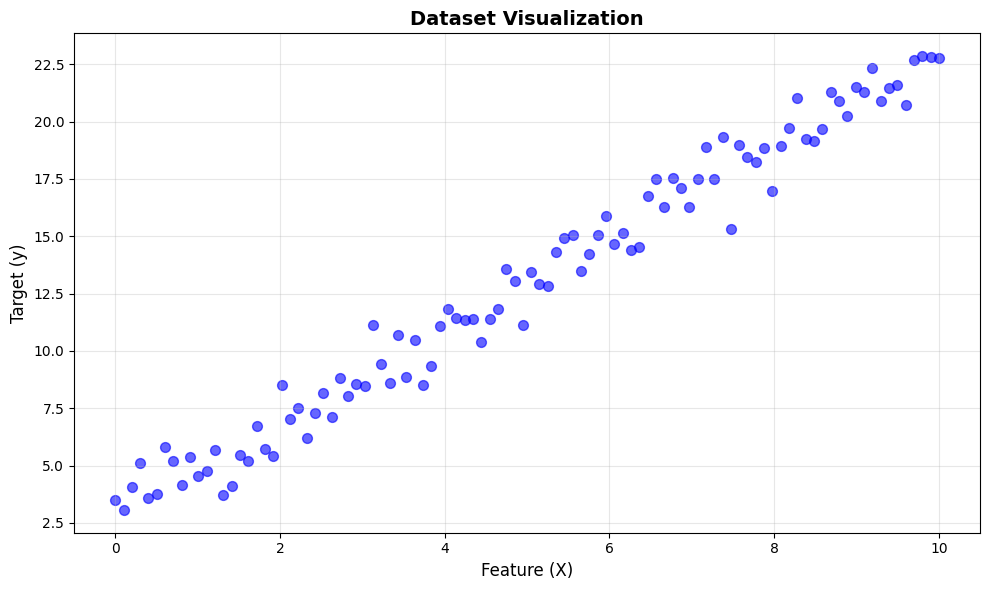

In [65]:
# Plot the dataset
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, color='blue', s=50)
plt.xlabel('Feature (X)', fontsize=12)
plt.ylabel('Target (y)', fontsize=12)
plt.title('Dataset Visualization', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Gradient Descent Implementation


In [66]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, max_iterations=1000, tolerance=1e-6):
        """
        Initialize Linear Regression with Gradient Descent.
        
        Parameters:
        learning_rate: Step size for gradient descent
        max_iterations: Maximum number of iterations
        tolerance: Convergence threshold
        """
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        """Train the model using gradient descent."""
        # Initialize parameters
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.cost_history = []
        
        # Gradient descent loop
        for i in range(self.max_iterations):
            # Predictions
            y_pred = X.dot(self.weights) + self.bias
            
            # Calculate cost (MSE)
            cost = np.mean((y_pred - y) ** 2)
            self.cost_history.append(cost)
            
            # Calculate gradients
            dw = (2 / n_samples) * X.T.dot(y_pred - y)
            db = (2 / n_samples) * np.sum(y_pred - y)
            
            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # Check for convergence
            if i > 0 and abs(self.cost_history[-2] - self.cost_history[-1]) < self.tolerance:
                print(f"Converged after {i+1} iterations")
                break
        
        return self

    def predict(self, X):
        """Make predictions."""
        return X.dot(self.weights) + self.bias

    def score(self, X, y):
        """Calculate R-squared score."""
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - (ss_res / ss_tot)


## Training the Model


In [67]:
# Train the model
model = LinearRegressionGD(learning_rate=0.003, max_iterations=400)
model.fit(X, y)

print(f"Learned weights: {model.weights}")
print(f"Learned bias: {model.bias:.4f}")
print(f"Final cost: {model.cost_history[-1]:.4f}")
print(f"R-squared score: {model.score(X, y):.4f}")


Learned weights: [2.21829082]
Learned bias: 1.4671
Final cost: 1.2858
R-squared score: 0.9636


## Visualizing the Results


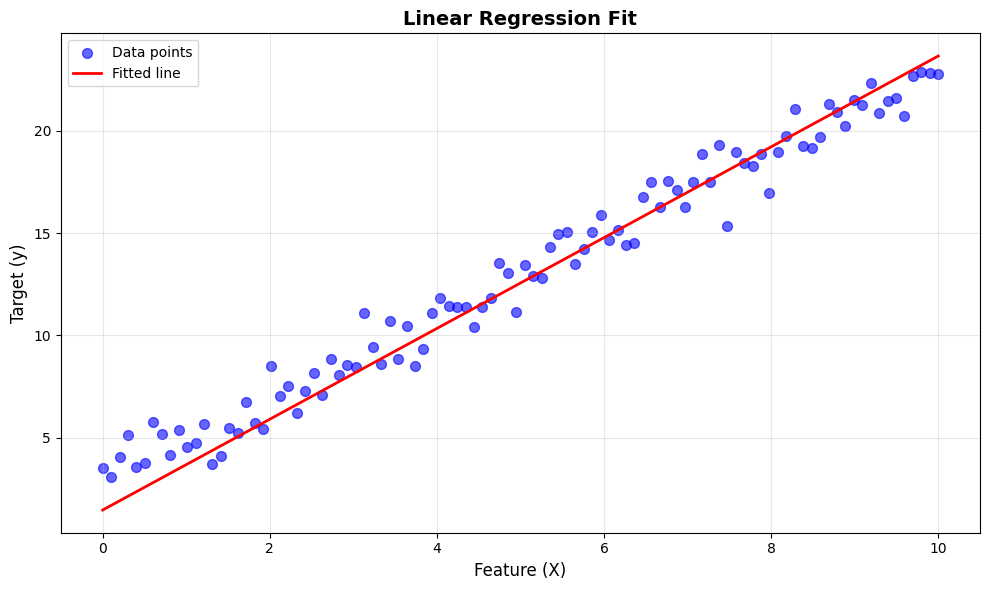

In [68]:
# Plot the data and fitted line
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, color='blue', s=50, label='Data points')
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(X_line)
plt.plot(X_line, y_line, 'r-', linewidth=2, label='Fitted line')
plt.xlabel('Feature (X)', fontsize=12)
plt.ylabel('Target (y)', fontsize=12)
plt.title('Linear Regression Fit', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


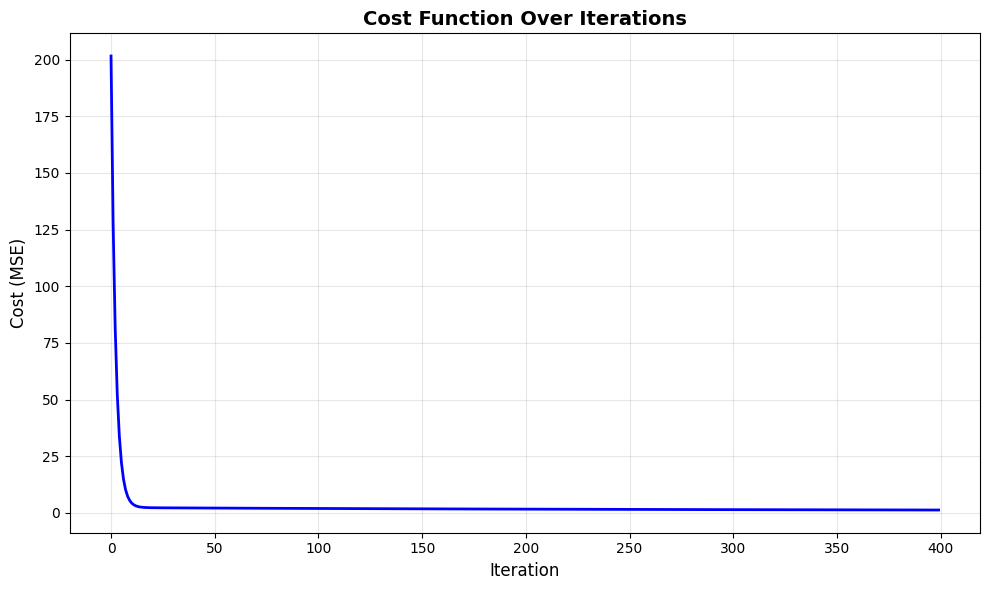

In [69]:
# Plot cost history
plt.figure(figsize=(10, 6))
plt.plot(range(len(model.cost_history)), model.cost_history, 'b-', linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost (MSE)', fontsize=12)
plt.title('Cost Function Over Iterations', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Testing Different Learning Rates


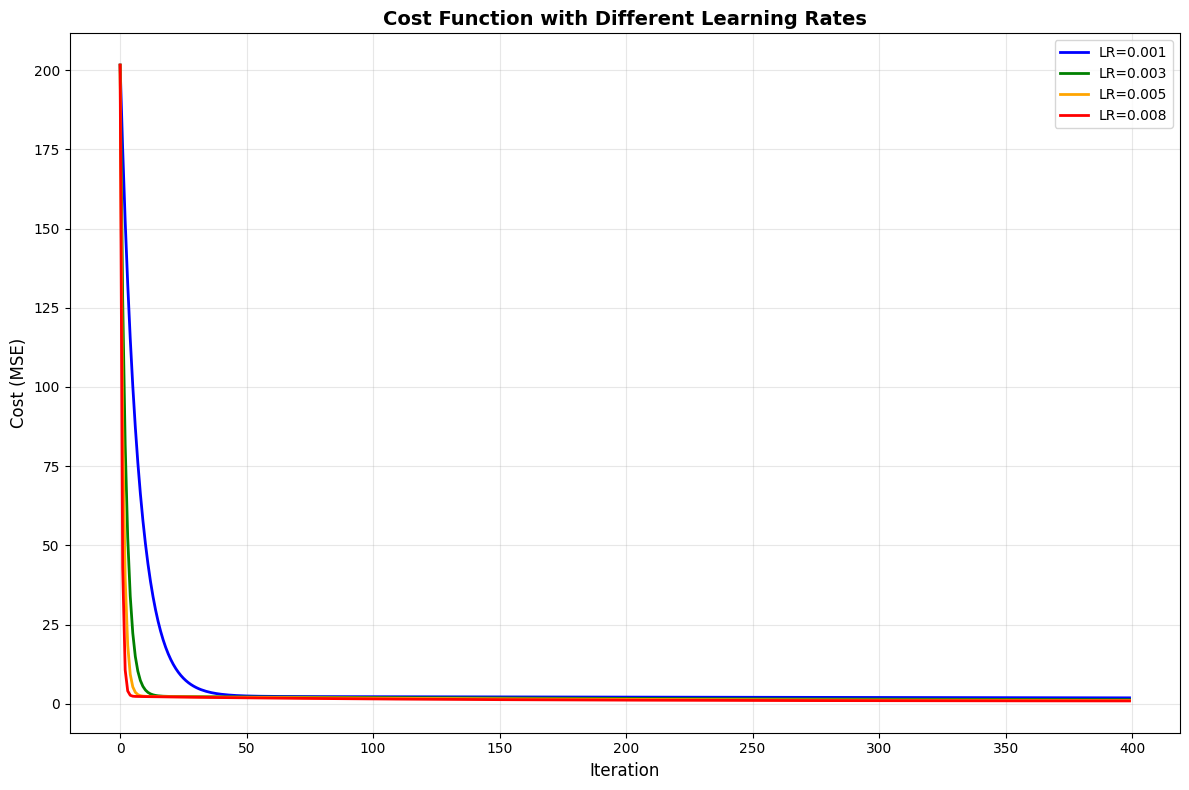

In [70]:
# Test different learning rates
learning_rates = [0.001, 0.003, 0.005, 0.008]
colors = ['blue', 'green', 'orange', 'red']

plt.figure(figsize=(12, 8))
for lr, color in zip(learning_rates, colors):
    model_test = LinearRegressionGD(learning_rate=lr, max_iterations=400)
    model_test.fit(X, y)
    plt.plot(range(len(model_test.cost_history)), model_test.cost_history, 
             color=color, linewidth=2, label=f'LR={lr}')
    
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost (MSE)', fontsize=12)
plt.title('Cost Function with Different Learning Rates', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Summary

In this notebook, we successfully implemented Gradient Descent from scratch and applied it to linear regression. Key takeaways:

1. **Gradient Descent finds optimal parameters** - it iteratively updates weights and bias to minimize cost
2. **Learning rate is critical** - too small and convergence is slow, too large and it may diverge
3. **Cost function decreases over iterations** - we can visualize the optimization process
4. **MSE measures prediction error** - lower MSE means better fit
5. **Convergence can be monitored** - we stop when cost changes are minimal

The implementation demonstrates the core optimization algorithm used in most machine learning training procedures, from simple linear models to deep neural networks.


## 2. Gradient Descent Methods with Scikit-Learn

There are three main types of Gradient Descent

- Batch Gradient Descent (what we implemented earlier)
- Stochastic Gradient Descent
- Mini-batch Gradient Descent

We'll implement:
- Linear regression using all 3 methods using the scikit-learn library
- Comparing the results and which worked the best

In [71]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [72]:
# Load the dataset
DATA_CSV = "../datasets/gradient_descent_comparison.csv"
df = pd.read_csv(DATA_CSV)
df.head()

# Separate features and target 
X = df[['feature_1', 'feature_2', 'feature_3']].values
y = df['target'].values


/var/folders/y8/tjhxjlzj4rq0l60s_sy7fl2m0000gn/T/ipykernel_60732/2964837509.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


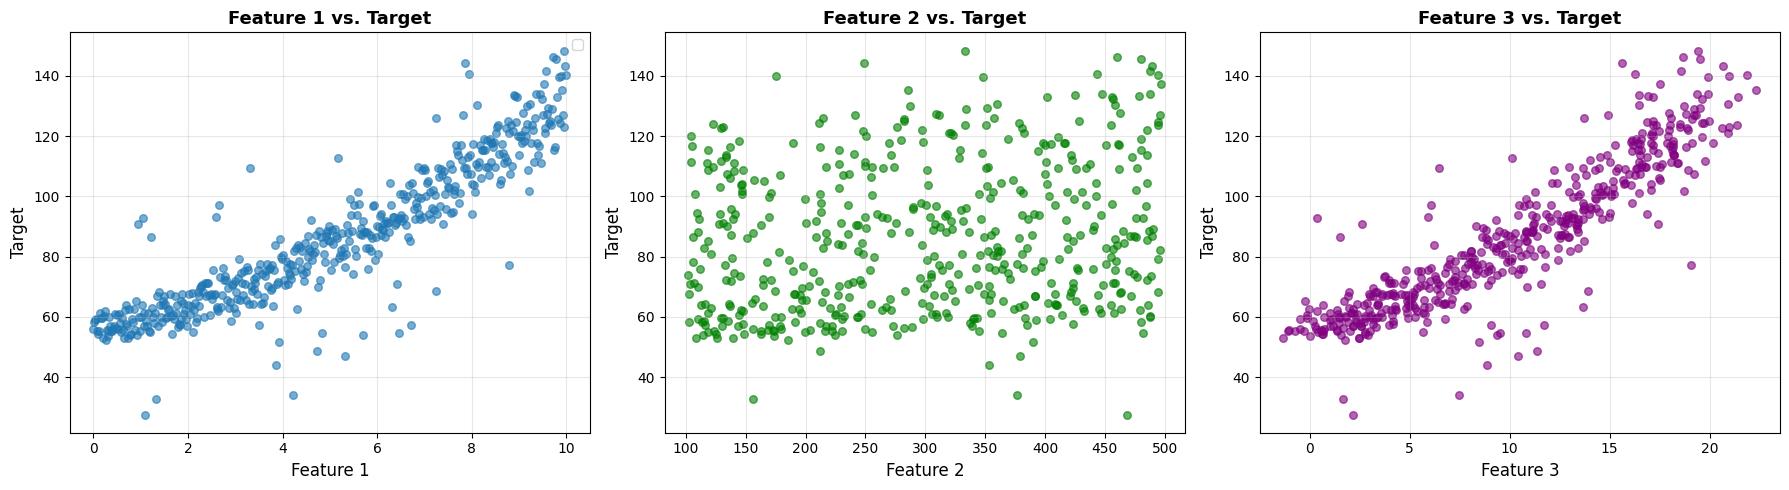

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Feature 1 vs Target (shows non-linearity and outliers)
ax1 = axes[0]
ax1.scatter(df['feature_1'], df['target'], alpha=0.6, s=30)
ax1.set_xlabel('Feature 1', fontsize=12)
ax1.set_ylabel('Target', fontsize=12)
ax1.set_title('Feature 1 vs. Target', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Feature 2 vs Target (different scale)
ax2 = axes[1]
ax2.scatter(df['feature_2'], df['target'], alpha=0.6, s=30, color='green')
ax2.set_xlabel('Feature 2', fontsize=12)
ax2.set_ylabel('Target', fontsize=12)
ax2.set_title('Feature 2 vs. Target', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Feature 3 vs Target
ax3 = axes[2]
ax3.scatter(df['feature_3'], df['target'], alpha=0.6, s=30, color='purple')
ax3.set_xlabel('Feature 3', fontsize=12)
ax3.set_ylabel('Target', fontsize=12)
ax3.set_title('Feature 3 vs. Target', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Stochastic Gradient Descent

In [74]:
# Standardize features for better convergence
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Updates after each example

sgd = SGDRegressor(
    max_iter=1000,
    tol=1e-3,
    learning_rate='constant',
    eta0=0.01,
    random_state=42
)
sgd.fit(X_scaled, y)
y_pred_sgd = sgd.predict(X_scaled)

mse_sgd = mean_squared_error(y, y_pred_sgd)
r2_sgd = r2_score(y, y_pred_sgd)

print(f"Final weights: {sgd.coef_[0]}")
print(f"Final bias: {sgd.intercept_[0]}")
print(f"Mean Squared Error: {mse_sgd}")
print(f"R squared Score: {r2_sgd}")
print(f"Number of iterations: {sgd.n_iter_}")

Final weights: 18.80788910415967
Final bias: 85.8059969018801
Mean Squared Error: 90.63934311663748
R squared Score: 0.8443737799772977
Number of iterations: 31


## Batch Gradient Descent

In [75]:
batch_gd = SGDRegressor(
    max_iter=1,
    tol=None,
    learning_rate='constant',
    eta0=0.01,
    random_state=42,
    warm_start=True
)

losses_batch = []
for i in range(1000):
    batch_gd.fit(X_scaled, y)
    y_pred_batch = batch_gd.predict(X_scaled)
    loss = mean_squared_error(y, y_pred_batch)
    losses_batch.append(loss)

y_pred_batch = batch_gd.predict(X_scaled)
mse_batch = mean_squared_error(y, y_pred_batch)
r2_batch = r2_score(y, y_pred_batch)

print(f"Final weights: {batch_gd.coef_}")
print(f"Final bias: {batch_gd.intercept_[0]}")
print(f"Mean Squared Error: {mse_batch}")
print(f"R squared Score: {r2_batch}")


Final weights: [20.98324821  4.48516482  2.21244605]
Final bias: 85.0375361918767
Mean Squared Error: 94.16731784089352
R squared Score: 0.8383163070103425


## Mini-batch Gradient Descent

In [76]:
# Using SGDRegressor configured for mini-batch behavior
batch_size = 32
n_epochs = 100

# Calculate iterations per epoch
samples_per_epoch = len(X_scaled)
iterations_per_epoch = int(np.ceil(samples_per_epoch / batch_size))

minibatch_gd = SGDRegressor(
    max_iter=1,
    tol=None,
    learning_rate='constant',
    eta0=0.01,
    random_state=42,
    warm_start=True
)

losses_minibatch = []

# Simulate mini-batch training
from sklearn.utils import shuffle
for epoch in range(n_epochs):
    # Shuffle data each epoch
    X_shuffled, y_shuffled = shuffle(X_scaled, y, random_state=epoch)
    
    # Process in mini-batches
    for i in range(0, len(X_shuffled), batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        minibatch_gd.partial_fit(X_batch, y_batch)
    
    # Record loss after each epoch
    y_pred_minibatch = minibatch_gd.predict(X_scaled)
    loss = mean_squared_error(y, y_pred_minibatch)
    losses_minibatch.append(loss)

y_pred_minibatch = minibatch_gd.predict(X_scaled)
mse_minibatch = mean_squared_error(y, y_pred_minibatch)
r2_minibatch = r2_score(y, y_pred_minibatch)

print(f"Batch size: {batch_size}")
print(f"Final weights: {minibatch_gd.coef_}")
print(f"Final bias: {minibatch_gd.intercept_[0]}")
print(f"Mean Squared Error: {mse_minibatch}")
print(f"R squared Score: {r2_minibatch}")

Batch size: 32
Final weights: [19.5658071   2.88933714  2.16753029]
Final bias: 85.99474667505771
Mean Squared Error: 90.30583808668126
R squared Score: 0.8449464024763802


## Predictions Comparison

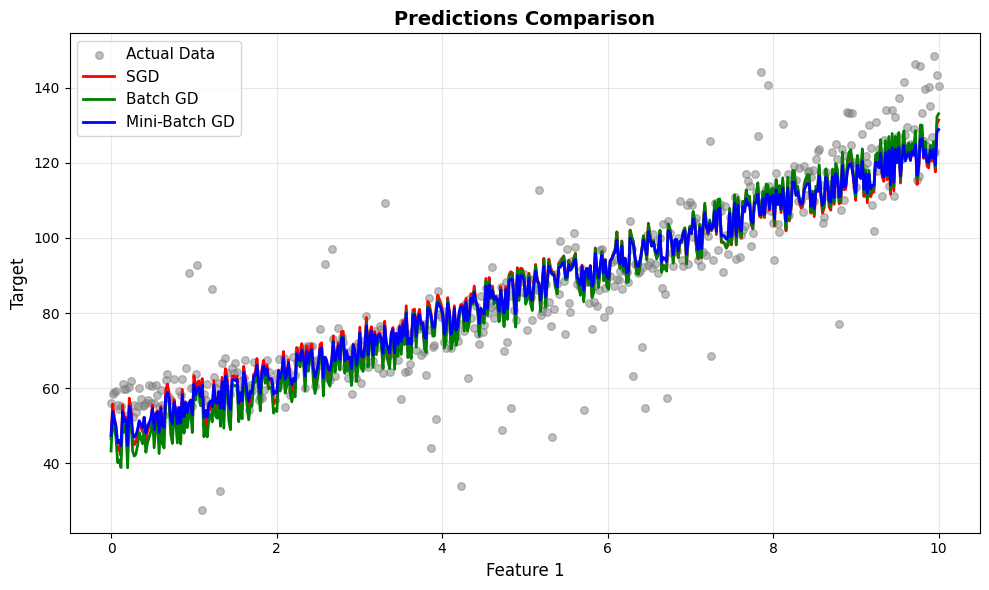

In [77]:
# Sort by feature_1 for cleaner line plots
sort_idx = np.argsort(X[:, 0]) # change the 0 value to see other features

plt.figure(figsize=(10, 6))
plt.scatter(X[sort_idx, 0], y[sort_idx], alpha=0.5, label='Actual Data', s=30, color='gray')
plt.plot(X[sort_idx, 0], y_pred_sgd[sort_idx], 'r-', label='SGD', linewidth=2)
plt.plot(X[sort_idx, 0], y_pred_batch[sort_idx], 'g-', label='Batch GD', linewidth=2)
plt.plot(X[sort_idx, 0], y_pred_minibatch[sort_idx], 'b-', label='Mini-Batch GD', linewidth=2)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Target', fontsize=12)
plt.title('Predictions Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Loss Convergence Over Time

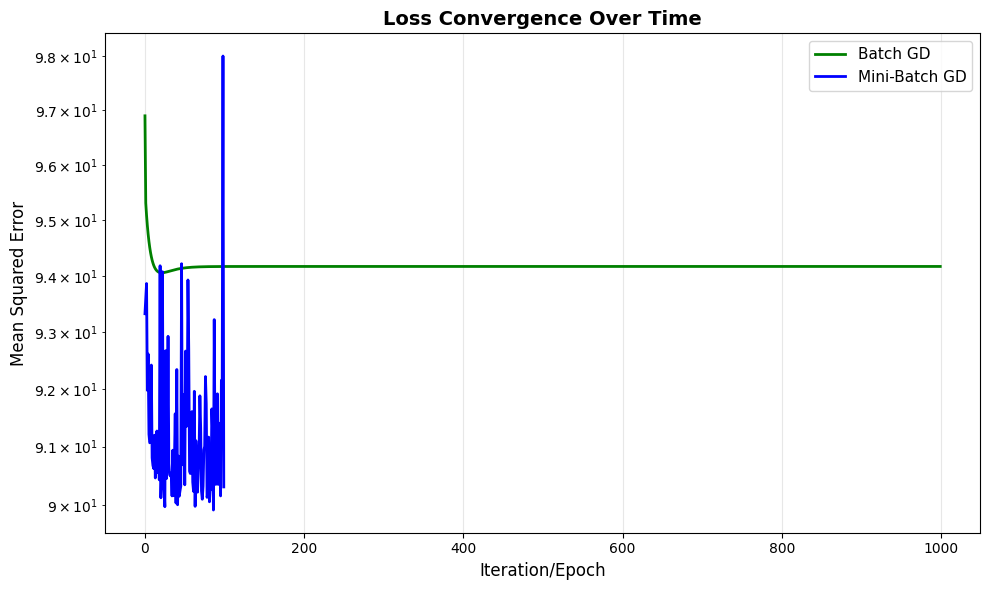

In [78]:
plt.figure(figsize=(10, 6))
plt.plot(losses_batch, 'g-', label='Batch GD', linewidth=2)
plt.plot(losses_minibatch, 'b-', label='Mini-Batch GD', linewidth=2)
plt.xlabel('Iteration/Epoch', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Loss Convergence Over Time', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

## Performance Metrics Comparison

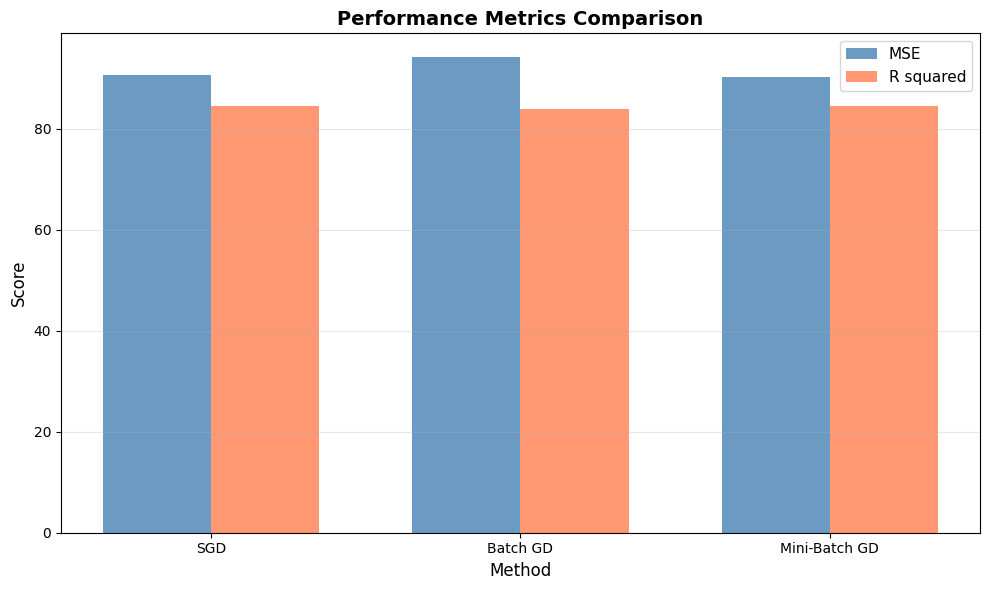

In [79]:
plt.figure(figsize=(10, 6))
methods = ['SGD', 'Batch GD', 'Mini-Batch GD']
mse_scores = [mse_sgd, mse_batch, mse_minibatch]
r2_scores = [r2_sgd, r2_batch, r2_minibatch]

x_pos = np.arange(len(methods))
width = 0.35

plt.bar(x_pos - width/2, mse_scores, width, label='MSE', alpha=0.8, color='steelblue')
plt.bar(x_pos + width/2, [r*100 for r in r2_scores], width, label='R squared', alpha=0.8, color='coral')

plt.xlabel('Method', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Performance Metrics Comparison', fontsize=14, fontweight='bold')
plt.xticks(x_pos, methods)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()